# Multi-modal RAG using FAISS

you will need either `brew install poppler` to run this notebook

### imports

In [1]:
import requests
import os
from pdf2image import convert_from_path
from transformers import AutoProcessor, AutoTokenizer, AutoModelForZeroShotImageClassification, AutoModelForImageTextToText
import faiss
from datasets import Dataset, Image
from collections import defaultdict
import matplotlib.pyplot as plt
import torch
import torch.nn
import PIL
import torchvision.transforms as T

### Functions

In [2]:
# converts all pdfs in the specified folder to a list of images (one per page) 
def convert_pdfs_to_images(pdf_folder):
    pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith(".pdf")]
    print(pdf_files)
    all_images = {}

    for doc_id, pdf_file in enumerate(pdf_files):
        pdf_path = os.path.join(pdf_folder, pdf_file)
        images = convert_from_path(pdf_path)
        all_images[doc_id] = images

    return all_images

# plot a list of images side by side
def plot_images(images, n_subplots):
    fig, axes = plt.subplots(1, min(len(images),n_subplots), figsize=(15, 10))

    for i, ax in enumerate(axes.flat):
        img = images[i]
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# cretaes a huggingface datset given a dict of pdfs, each pdf is a list of images 
def create_hf_dataset(images: dict):

    ds_dict = defaultdict(list)
    for i, pdf in images.items():
        for j, image in enumerate(pdf):
            ds_dict['file'].append(i)
            ds_dict['page'].append(j)
            ds_dict['image'].append(image)

    return Dataset.from_dict(ds_dict)

# add an extra column to the dataset containing the embeddings of images
def add_img_embedding_column(ds, model, processor, existing_col_name="image", new_col_name="image_embeddings"):
    ds_with_embeddings = ds.map(
        lambda example: {
            new_col_name: model.get_image_features(**processor(images=[example[existing_col_name]], return_tensors="pt"))[0].detach().numpy()
        }
    )
    return ds_with_embeddings

# add an extra column to the dataset containing the embeddings of texts (not used yet)
def add_txt_embedding_column(ds, model, processor, existing_col_name="text", new_col_name="text_embeddings"):
    ds_with_embeddings = ds.map(
        lambda example: {
            new_col_name: model.get_text_features(**processor(images=[example[existing_col_name]], return_tensors="pt"))[0].detach().numpy()
        }
    )
    return ds_with_embeddings

# find images close to the provided prompt in embedding space
def retrieve_images_by_prompt(prompt, ds_with_faiss, model, tokenizer, topk):
    prompt_embedding = (
        model.get_text_features(**tokenizer([prompt], return_tensors="pt", truncation=True))[0].detach().numpy()
    )
    scores, retrieved_examples = ds_with_faiss.get_nearest_examples("image_embeddings", prompt_embedding, k=topk)
    plot_images(retrieved_examples["image"], topk)
    return scores, retrieved_examples

# normalization means and stdvs for RGB images
image_mean = torch.tensor([
    0.48145466,
    0.4578275,
    0.40821073
  ])
image_std = torch.tensor([
    0.26862954,
    0.26130258,
    0.27577711
  ])

# reverse the effect of image normalization
def unnormalize_image(image):
    image = image * image_std.unsqueeze(-1).unsqueeze(-1) + image_mean.unsqueeze(-1).unsqueeze(-1)
    return image.clip(0,1)

### Download IKEA PDFs

In [ ]:
pdfs = {
    "MALM": "https://www.ikea.com/us/en/assembly_instructions/malm-4-drawer-chest-white__AA-2398381-2-100.pdf",
    "BILLY": "https://www.ikea.com/us/en/assembly_instructions/billy-bookcase-white__AA-1844854-6-2.pdf",
    "BOAXEL": "https://www.ikea.com/us/en/assembly_instructions/boaxel-wall-upright-white__AA-2341341-2-100.pdf",
    "ADILS": "https://www.ikea.com/us/en/assembly_instructions/adils-leg-white__AA-844478-6-2.pdf",
    "MICKE": "https://www.ikea.com/us/en/assembly_instructions/micke-desk-white__AA-476626-10-100.pdf",
}

data_dir = "../data/ikea"
os.makedirs(data_dir, exist_ok=True)

for name, url in pdfs.items():
    response = requests.get(url)
    pdf_path = os.path.join(data_dir, f"{name}.pdf")

    with open(pdf_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded {name} to {pdf_path}")

print("Downloaded files:", os.listdir(data_dir))

Downloaded MALM to data/ikea/MALM.pdf
Downloaded BILLY to data/ikea/BILLY.pdf
Downloaded BOAXEL to data/ikea/BOAXEL.pdf
Downloaded ADILS to data/ikea/ADILS.pdf
Downloaded MICKE to data/ikea/MICKE.pdf
Downloaded files: ['MICKE.pdf', 'BOAXEL.pdf', 'ADILS.pdf', 'MALM.pdf', 'BILLY.pdf']


### Convert each PDF page to an Image 

['MICKE.pdf', 'BOAXEL.pdf', 'ADILS.pdf', 'MALM.pdf', 'BILLY.pdf']
[24, 20, 8, 28, 16]


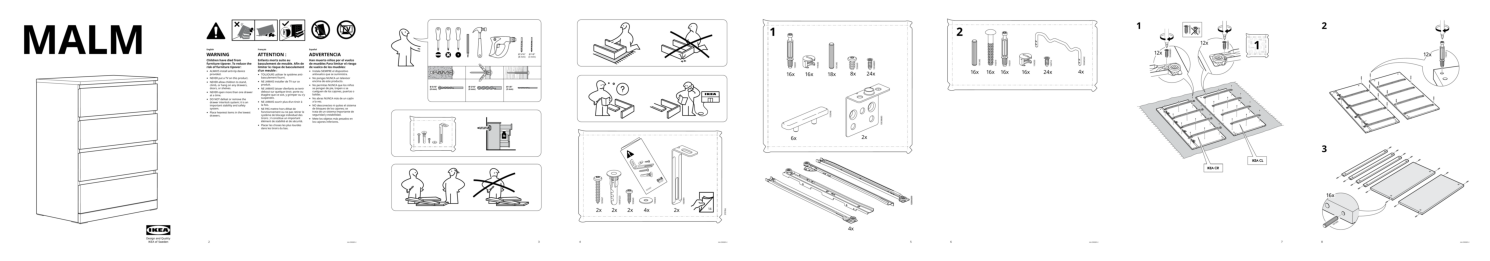

In [4]:
all_images = convert_pdfs_to_images(data_dir)
print([len(pdf) for pdf in all_images.values()])
plot_images(all_images[3], n_subplots=8)

### create a HF Dataset

In [5]:
ds = create_hf_dataset(all_images)
len(ds)

96

### Load Embedding Model

In [6]:
model_name = "openai/clip-vit-base-patch16" # "openai/clip-vit-base-patch16", "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1"

processor = AutoProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForZeroShotImageClassification.from_pretrained(model_name)

### Create Embeddings and FAISS Retriever 

In [7]:
ds_with_embeddings = add_img_embedding_column(ds, model, processor, existing_col_name="image", new_col_name="image_embeddings")
ds_with_embeddings.add_faiss_index(column="image_embeddings")

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Dataset({
    features: ['file', 'page', 'image', 'image_embeddings'],
    num_rows: 96
})

### Test Retrieval

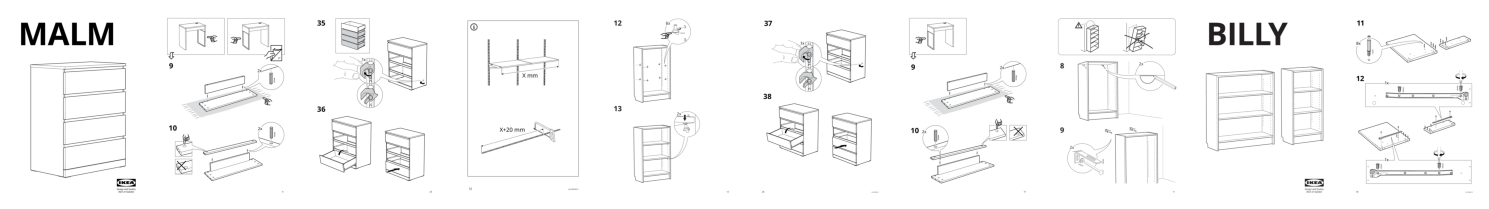

(array([124.16735, 136.1488 , 136.91074, 138.18219, 138.3454 , 138.73148,
        139.19637, 139.28435, 139.75215, 139.86453], dtype=float32),
 [3, 0, 3, 1, 4, 3, 0, 4, 4, 0])

In [8]:
prompt = "How does the MALM look like?"
topk = 10

scores, retrieved = retrieve_images_by_prompt(prompt, ds_with_embeddings, model, tokenizer, topk)
scores, retrieved['file']

### Create Adversarial example

In [9]:
# index 24 corresponds to first page of BOAXEL (irrelevant to query), index 52 corresponds to the correct photo (MALM)
irrelevant_image = ds_with_embeddings[24]["image"]
image_input = processor(images=[irrelevant_image], return_tensors='pt')
# store the initial image before perturbation
initial_image = image_input['pixel_values'].clone()

In [10]:
lr = 5e-3
n_iters = 50


# computes an adversarial example by perturbing the image so that its embeddgings are close to those of the prompt text
def adversarial_attack_fgsm_iterative(image_input, model, prompt, n_iters, lr):
    image_input['pixel_values'].requires_grad = True
    prompt_embedding = model.get_text_features(**tokenizer([prompt], return_tensors="pt", truncation=True))[0].detach()
    
    for i in range(n_iters):
        image_features = model.get_image_features(**image_input)[0]

        loss = torch.nn.functional.mse_loss(image_features, prompt_embedding)
        if i%10==0: print(i, loss.item())

        grads = torch.autograd.grad(loss, image_input['pixel_values'])

        with torch.no_grad():
            image_input['pixel_values'] -= lr * torch.sign(grads[0])
        
    return image_input

image_adv = adversarial_attack_fgsm_iterative(image_input, model, prompt, n_iters, lr)
print(f"perturbation MSE : {torch.nn.functional.mse_loss(image_adv['pixel_values'], initial_image)}")

0 0.2974138557910919
10 0.1879103183746338
20 0.1728491485118866
30 0.16135279834270477
40 0.15487301349639893
perturbation MSE : 0.0016051491256803274


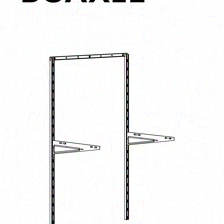

In [11]:
# convert image tensor to PIL image
transform = T.ToPILImage()
image = transform(unnormalize_image(image_input['pixel_values'][0]))
image

### Create a new Dataset with the adverarial Image

In [12]:
# add a new dict entry for the adversarial image
all_images[100]=[image]
# create a new dataset
ds_adv = create_hf_dataset(all_images)
ds_adv_with_embeddings = add_img_embedding_column(ds_adv, model, processor, existing_col_name="image", new_col_name="image_embeddings")
ds_adv_with_embeddings.add_faiss_index(column="image_embeddings") 

Map:   0%|          | 0/97 [00:00<?, ? examples/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Dataset({
    features: ['file', 'page', 'image', 'image_embeddings'],
    num_rows: 97
})

### Test Retrieval with the Corrupted Dataset

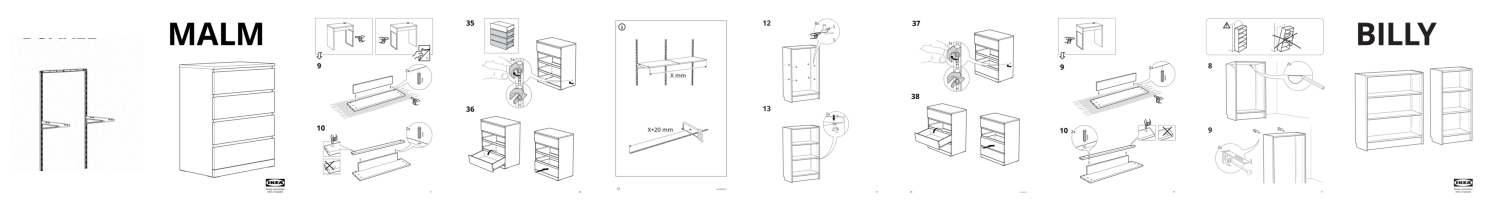

(array([ 82.86597, 124.16735, 136.1488 , 136.91074, 138.18219, 138.3454 ,
        138.73148, 139.19637, 139.28435, 139.75215], dtype=float32),
 [100, 3, 0, 3, 1, 4, 3, 0, 4, 4])

In [13]:
topk=10
scores, retrieved = retrieve_images_by_prompt(prompt, ds_adv_with_embeddings, model, tokenizer, topk)
scores, retrieved["file"]